# **Check Class Imbalance**

### **Objective**
Confirm the class balance of the target (`Status`) on `y_train` and decide
whether — and how — to handle the imbalance before training models.

**1-Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight


**2-Load y_train**

In [2]:
y_train = pd.read_csv("y_train.csv").squeeze()
print(y_train.shape)
y_train.head()


(35000,)


,Status
0,0
1,0
2,0
3,0
4,1


**3-Quantify the Imbalance**

In [3]:
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100
print("Counts:\n", counts)
print("\nPercentages:\n", percentages)
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")


Counts:
 Status
0    26375
1     8625
Name: count, dtype: int64

Percentages:
 Status
0    75.357143
1    24.642857
Name: proportion, dtype: float64

Imbalance ratio (majority : minority) = 3.06 : 1


**4-Visualize the Class Balance**

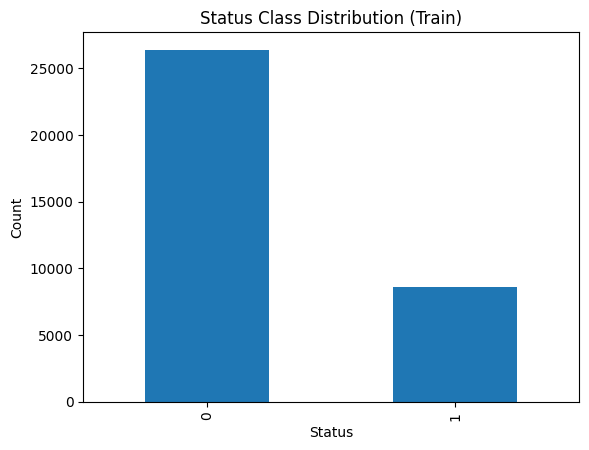

In [4]:
counts.plot(kind="bar")
plt.title("Status Class Distribution (Train)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


**5-Options for Handling Imbalance**

In [5]:
class_weights = compute_class_weight(class_weight="balanced",classes=np.unique(y_train),y=y_train)
classes = np.unique(y_train)
class_weight_dict = {}
for i in range(len(classes)):
    class_weight_dict[classes[i]] = class_weights[i]

print(class_weight_dict)

{np.int64(0): np.float64(0.6635071090047393), np.int64(1): np.float64(2.028985507246377)}


**7-(Optional) SMOTE — Only If Class Weights Aren't Enough**



In [ ]:
# from imblearn.over_sampling import SMOTE
# X_train_processed = pd.read_csv("X_train_processed.csv")
# smote = SMOTE(random_state=42)
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed,y_train)
# print("Before SMOTE:")
# print(y_train.value_counts())
# print("\nAfter SMOTE:")
# print(y_train_balanced.value_counts())


**8-Save the Class Weights for the Modeling Step**

In [6]:
import json
weights = {str(key): value for key, value in class_weight_dict.items()}
with open("class_weights.json", "w") as file:
    json.dump(weights, file, indent=4)